In [40]:
import kaleidocell
import scanpy as sc
import matplotlib.pyplot as plt


In [ ]:
adata = sc.read_h5ad('/net/bq-storage/ag-cherrmann/bq_cinac/data/extendedGBmap.h5ad')

In [25]:
# in obs annotation_level_2, select the variables (cell types) that are immune cell types. Subset the adata for those cells and save a copy to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/immune_cells_extended_gbmap.h5ad
print(adata.obs["annotation_level_2"].value_counts())

annotation_level_2
Myeloid     524414
Lymphoid    109296
Name: count, dtype: int64


In [26]:
# Subset for immune cells
immune_cells = adata[adata.obs["annotation_level_2"].isin(["Myeloid", "Lymphoid"])].copy()
print(immune_cells)

immune_cells = immune_cells.to_memory()

AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_approximate_distribution', 'batch_condition

In [ ]:
#immune_cells.write('/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/immune_cells_extended_gbmap.h5ad')

In [23]:
# Run kaleidocell on the dataset. To check more fine grained annotations, check obs "annotation_level_3" and "annotation_level_4"
adata_lvl2 = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/immune_cells_extended_gbmap.h5ad")

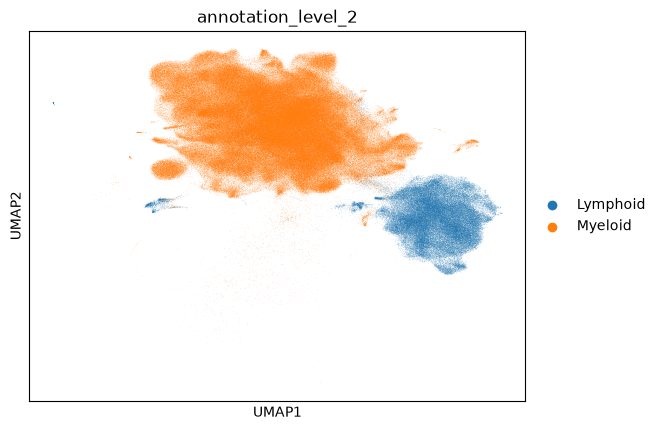

<Figure size 640x480 with 0 Axes>

In [41]:
sc.pl.umap(adata_lvl2, color = ['annotation_level_2'])

plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/umap_annotation_level_2.png", dpi=150, bbox_inches="tight")

In [27]:
print(adata.obs["annotation_level_3"].value_counts())

annotation_level_3
TAM-BDM       267733
TAM-MG        200606
CD4/CD8       101945
Mono           41018
DC              9124
Neutrophil      5117
NK              3151
B cell          2657
Plasma B        1543
Mast             816
Name: count, dtype: int64


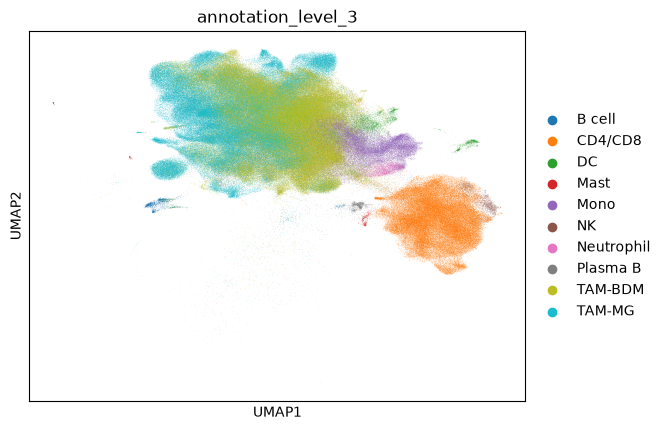

<Figure size 640x480 with 0 Axes>

In [42]:
sc.pl.umap(adata_lvl2, color = ['annotation_level_3'])

plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/umap_annotation_level_3.png", dpi=150, bbox_inches="tight")

In [54]:
print(immune_cells.obs.columns.tolist())

['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


In [36]:
print(adata_lvl2.obs.columns.tolist())
print(adata.obs["annotation_level_1"].value_counts())
print(adata.obs["annotation_level_2"].value_counts())
print(adata.obs["celltype_original"].value_counts())




['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']
annotation_level_1
Non-neoplastic    633710
Name: count, dtype: int64
annotation_level_2
Myeloid     524414
Lymphoid    109296
Name: count, dtype: int64
celltype_original
unknown                  353878
Microglia                 43124
Macrophage                39239
Immune cell               26140
CD8+                      18630
                          ...  
MES-like              

In [43]:
print(f"kaleidocell version: {kaleidocell.__version__}")


kaleidocell version: 0.1.2


In [ ]:
print(f"{adata.obs['annotation_level_3'].unique()[0]}: {adata.n_obs} cells")

In [46]:
print(immune_cells.obs.columns.tolist())
print(immune_cells.obs["donor_id"].nunique())


['author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']
234


In [48]:
results_nmf, nmf_convergence = kaleidocell.multi_sample_nmf(
    immune_cells,
    batch_key="donor_id",
    test_ranks=[4, 5, 6, 7, 8, 9],
    n_initializations=1,
    max_iterations=100
)

Running multi-sample NMF on 234 samples.
Tested ranks: [4, 5, 6, 7, 8, 9]


Global NMF Progress:   0%|          | 0/140400 [00:00<?, ?it/s]

/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/nmf.py:104: UserWarning: Number of rows/columns is smaller than rank; results may be unstable.
  warnings.warn(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/nmf.py:104: UserWarning: Number of rows/columns is smaller than rank; results may be unstable.
  warnings.warn(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/nmf.py:104: UserWarning: Number of rows/columns is smaller than rank; results may be unstable.
  warnings.warn(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/nmf.py:104: UserWarning: Number of rows/columns is smaller than rank; results may be unstable.
  warnings.warn(
/net/bq-storage/ag-cherrmann/bq_cinac/pr

Multi-sample NMF complete.


In [50]:
results_mp = kaleidocell.derive_nmf_metaprograms(results_nmf)
print(results_mp["metrics"])

Total number of programs: 9126
Optimal number of meta-programs: 9
Clustering using hierarchical Ward linkage
Defining meta-program consensus
Computing meta-program metrics
Meta-program derivation complete.
     sampleCoverage  silhouette  meanSimilarity  nPrograms  nGenes
MP1        0.709402    0.284663           0.336       1040      60
MP2        0.405983    0.170204           0.253        404      32
MP3        0.760684   -0.033949           0.094       1479      68
MP4        0.414530    0.263550           0.328        325      65
MP5        0.841880   -0.037123           0.040       3348    9581
MP6        0.376068    0.278157           0.376        322       6
MP7        0.645299    0.047897           0.188        923      42
MP8        0.311966    0.375676           0.456        275      10
MP9        0.653846    0.045493           0.174       1010     168


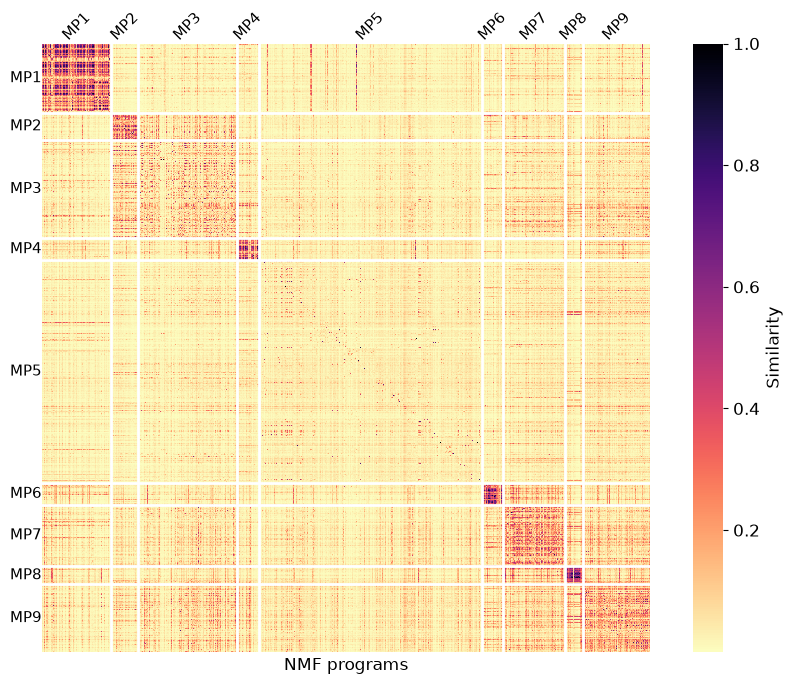

In [51]:
kaleidocell.plot_heatmap(results_mp)


In [52]:
mp_scores = kaleidocell.compute_mp_scores(results_mp, adata_lvl2)
mp_scores.head()

Computing module scores per MP.
Finished computing MP scores.


,MP1_score,MP2_score,MP3_score,MP4_score,MP5_score,MP6_score,MP7_score,MP8_score,MP9_score
PJ017_2-0,-0.244496,0.034972,0.604009,0.128960,0.173924,-0.297089,-0.086652,-0.247786,0.408172
PJ017_16-0,-0.160033,-0.027380,0.202139,-0.107929,0.128070,-0.038705,-0.357842,0.453310,0.216197
PJ017_17-0,-0.242230,0.107331,0.665775,0.046734,0.152368,1.228976,0.244032,-0.401646,0.843632
PJ017_34-0,-0.208052,0.048299,0.443217,-0.115880,0.134363,0.274334,-0.156723,0.483473,0.300187
PJ017_40-0,-0.198523,0.063902,0.494984,-0.087754,0.126471,-0.072902,-0.103550,-0.049152,0.408626


In [53]:
mp_scores = kaleidocell.compute_mp_scores(results_mp, immune_cells)
mp_scores.head()

Computing module scores per MP.
Finished computing MP scores.


,MP1_score,MP2_score,MP3_score,MP4_score,MP5_score,MP6_score,MP7_score,MP8_score,MP9_score
PJ017_2-0,-0.244496,0.034972,0.604009,0.128960,0.173924,-0.297089,-0.086652,-0.247786,0.408172
PJ017_16-0,-0.160033,-0.027380,0.202139,-0.107929,0.128070,-0.038705,-0.357842,0.453310,0.216197
PJ017_17-0,-0.242230,0.107331,0.665775,0.046734,0.152368,1.228976,0.244032,-0.401646,0.843632
PJ017_34-0,-0.208052,0.048299,0.443217,-0.115880,0.134363,0.274334,-0.156723,0.483473,0.300187
PJ017_40-0,-0.198523,0.063902,0.494984,-0.087754,0.126471,-0.072902,-0.103550,-0.049152,0.408626


In [55]:
print(immune_cells.obs_names.equals(adata_lvl2.obs_names))

True


In [ ]:
print([col for col in ["annotation_level_2", "annotation_level_3", "stage", "location"] if col in immune_cells.obs.columns])

['annotation_level_2', 'stage', 'location']


In [57]:
path = kaleidocell.get_html(
    results_mp,
    immune_cells,
    mp_scores=mp_scores,
    obs=["annotation_level_2", "annotation_level_3", "stage", "location", "sector", "disease"],
    output_path="/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/"
)
print(f"Report written to: {path}")

Rendering heatmap…
Rendering UMAP scores…
Building metrics table…
Running GSEA — GO Biological Process…
Ensembl gene IDs detected — translating to HGNC using bundled table.
Building gene table…
Rendering violin plots for 'annotation_level_2'…
Plotting MP distributions across 'annotation_level_2'.


/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Pas

Finished plotting MP distributions.
Rendering violin plots for 'annotation_level_3'…
Plotting MP distributions across 'annotation_level_3'.


/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Pas

Finished plotting MP distributions.
Rendering violin plots for 'stage'…
Plotting MP distributions across 'stage'.


...

Finished plotting MP distributions.
Rendering violin plots for 'sector'…
Plotting MP distributions across 'sector'.


/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Pas

Finished plotting MP distributions.
Rendering violin plots for 'disease'…
Plotting MP distributions across 'disease'.


/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=batch_key, y=score_col, palette=palette, inner="box")
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/kaleidocell/visualization.py:360: FutureWarning: 

Pas

Finished plotting MP distributions.

Files written to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/
  results.html
  gsea_GO_Biological_Process.csv
  genes.csv
Report written to: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01/results.html
